# 📊 Análise de Marketing e Unit Economics — Y.Afisha

### 🎯 Objetivo

Este projeto tem como objetivo analisar o comportamento dos usuários, as vendas e os investimentos em marketing da plataforma Y.Afisha.

A partir dessa análise, será possível identificar oportunidades de otimização dos investimentos em marketing e apoiar a tomada de decisão estratégica.

### 📌 Principais insights

- Baixa retenção de usuários ao longo do tempo
- Conversão rápida: a maioria dos usuários realiza a compra no mesmo dia da primeira visita
- Ticket médio baixo na maior parte das transações
- Forte dependência de poucos clientes com alto valor (LTV)
- Grande variação de eficiência entre canais de marketing (CAC e ROI)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set(style='whitegrid')
sns.set_context("talk")
palette = 'viridis'
plt.rcParams['figure.figsize'] = (12,5)

### 📥 Carregamento dos Dados

Nesta etapa, os dados serão carregados para análise.

Os arquivos utilizados são:

- Visits: dados de acesso dos usuários  
- Orders: dados de compras  
- Costs: dados de investimento em marketing  

In [3]:
visits = pd.read_csv('/datasets/visits_log_us.csv')
orders = pd.read_csv('/datasets/orders_log_us.csv')
costs = pd.read_csv('/datasets/costs_us.csv')

In [4]:
visits = visits.rename(columns={
    'Start Ts': 'start_ts',
    'End Ts': 'end_ts',
    'Source Id': 'source_id',
    'Uid': 'uid'
})

orders = orders.rename(columns={
    'Buy Ts': 'buy_ts',
    'Revenue': 'revenue',
    'Uid': 'uid'
})

costs = costs.rename(columns={
    'dt': 'dt',
    'source_id': 'source_id',
    'costs': 'costs'
})

### 🔍 Visualização Inicial dos Dados

Vamos observar as primeiras linhas de cada conjunto de dados para entender sua estrutura.

In [5]:
visits.head()

,Device,end_ts,source_id,start_ts,uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [6]:
orders.head()

,buy_ts,revenue,uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [7]:
costs.head()

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


### 🧾 Estrutura dos Dados

Agora vamos analisar os tipos de dados e verificar possíveis problemas, como valores ausentes.

In [8]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   end_ts     359400 non-null  object
 2   source_id  359400 non-null  int64 
 3   start_ts   359400 non-null  object
 4   uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


In [9]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   buy_ts   50415 non-null  object 
 1   revenue  50415 non-null  float64
 2   uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


In [10]:
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


### 🧹 Pré-processamento dos Dados

Nesta etapa, iremos preparar os dados para análise.

Principais ações:
- Converter colunas de data para o tipo datetime
- Garantir que os dados estejam no formato correto para cálculos e agrupamentos

In [11]:
visits['start_ts'] = pd.to_datetime(visits['start_ts'])
visits['end_ts'] = pd.to_datetime(visits['end_ts'])

orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])

costs['dt'] = pd.to_datetime(costs['dt'])

In [12]:
visits['date'] = visits['start_ts'].dt.floor('D')
visits['week'] = visits['start_ts'].dt.to_period('W')
visits['month'] = visits['start_ts'].dt.to_period('M')

In [13]:
dau = visits.groupby('date')['uid'].nunique()

In [14]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  object        
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  uint64        
 5   date       359400 non-null  datetime64[ns]
 6   week       359400 non-null  period[W-SUN] 
 7   month      359400 non-null  period[M]     
dtypes: datetime64[ns](3), int64(1), object(1), period[M](1), period[W-SUN](1), uint64(1)
memory usage: 21.9+ MB


## 📊 Análise de Produto

Nesta seção, iremos analisar como os usuários interagem com a plataforma.

Serão avaliadas métricas como:

- DAU (Daily Active Users)
- Número de sessões
- Duração das sessões
- Frequência de retorno dos usuários (retenção por coorte)

### 👥 Usuários por Dia (DAU)

Vamos calcular quantos usuários únicos acessam a plataforma por dia (DAU), semana (WAU) e mês (MAU).

In [15]:
dau = visits.groupby('date')['uid'].nunique()
wau = visits.groupby('week')['uid'].nunique()
mau = visits.groupby('month')['uid'].nunique()

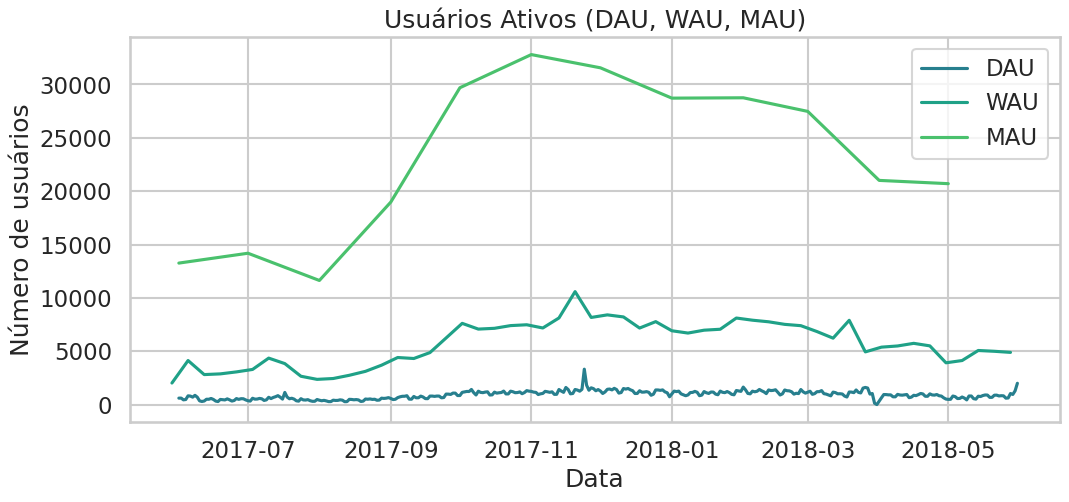

In [16]:

plt.figure(figsize=(12,5))

plt.plot(
    dau.index,
    dau.values,
    label='DAU',
    color=sns.color_palette(palette)[2]
)

plt.plot(
    wau.index.to_timestamp(),
    wau.values,
    label='WAU',
    color=sns.color_palette(palette)[3]
)

plt.plot(
    mau.index.to_timestamp(),
    mau.values,
    label='MAU',
    color=sns.color_palette(palette)[4]
)

plt.title('Usuários Ativos (DAU, WAU, MAU)')
plt.xlabel('Data')
plt.ylabel('Número de usuários')

plt.legend()
plt.grid(True)

plt.show()


### 📌 Interpretação

Os dados mostram que a quantidade de usuários ativos cresce ao longo do período analisado.

O DAU (usuários diários) aumenta de cerca de 605 no início para aproximadamente 1997 no final, indicando crescimento da base de usuários ao longo do tempo. Esse comportamento também é observado no WAU e MAU, que apresentam aumento consistente.

Os maiores valores de atividade ocorrem em novembro de 2017, com picos de 3319 usuários diários, 10586 semanais e 32797 mensais, possivelmente relacionados a campanhas de marketing ou eventos específicos.

Apesar do crescimento, a diferença entre MAU, WAU e DAU indica que apenas uma parte dos usuários retorna com frequência diária. Isso sugere que a plataforma consegue atrair usuários, mas ainda apresenta baixa recorrência de uso.

De forma geral, os dados indicam crescimento da base de usuários, mas com oportunidades de melhoria na retenção e engajamento.

### 📊 Número de Sessões por Dia

Vamos calcular quantas sessões ocorrem por dia. Um usuário pode realizar várias sessões.

In [17]:
sessions_per_day = visits.groupby('date').size()

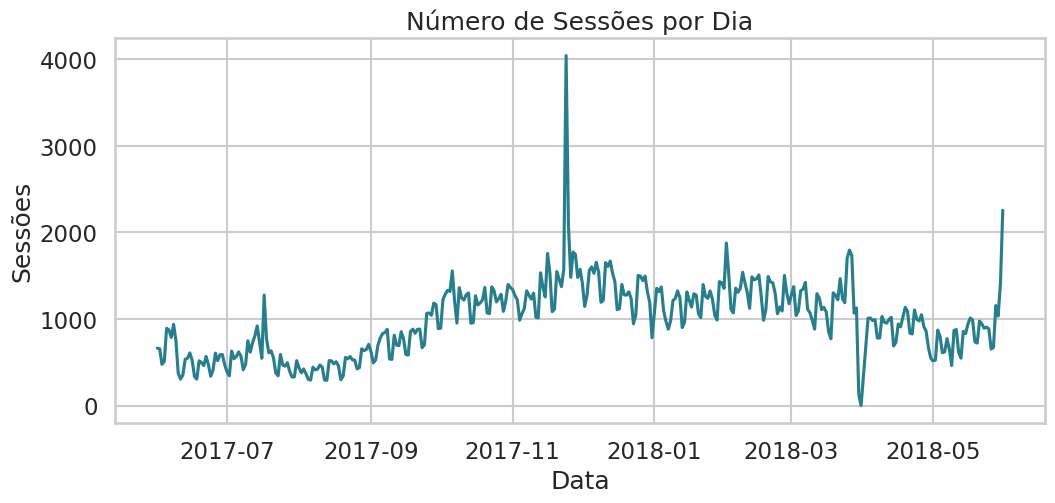

In [18]:
plt.figure(figsize=(12,5))

plt.plot(
    sessions_per_day.index,
    sessions_per_day.values,
    color=sns.color_palette(palette)[2]
)

plt.title('Número de Sessões por Dia')
plt.xlabel('Data')
plt.ylabel('Sessões')

plt.grid(True)

plt.show()

### 📌 Interpretação

O número de sessões por dia apresenta crescimento ao longo do período analisado.

No início, são registradas cerca de 664 sessões diárias, enquanto no final esse valor chega a aproximadamente 2256, indicando aumento na atividade dos usuários na plataforma.

O pico ocorre em novembro de 2017, com 4042 sessões em um único dia, o que pode indicar influência de fatores externos, como campanhas ou sazonalidade.

Ao comparar com o número de usuários únicos (DAU), observa-se que o volume de sessões é maior, o que indica que alguns usuários acessam a plataforma mais de uma vez no mesmo dia.

No entanto, como essa diferença não é muito elevada, isso sugere que a maioria dos usuários realiza apenas uma sessão por dia, indicando um nível moderado de engajamento.

### ⏱️ Duração das Sessões

Vamos analisar quanto tempo, em média, os usuários passam em cada sessão.

In [19]:
visits['session_duration'] = (visits['end_ts'] - visits['start_ts']).dt.total_seconds()

In [20]:
visits = visits[visits['session_duration'] >= 0]

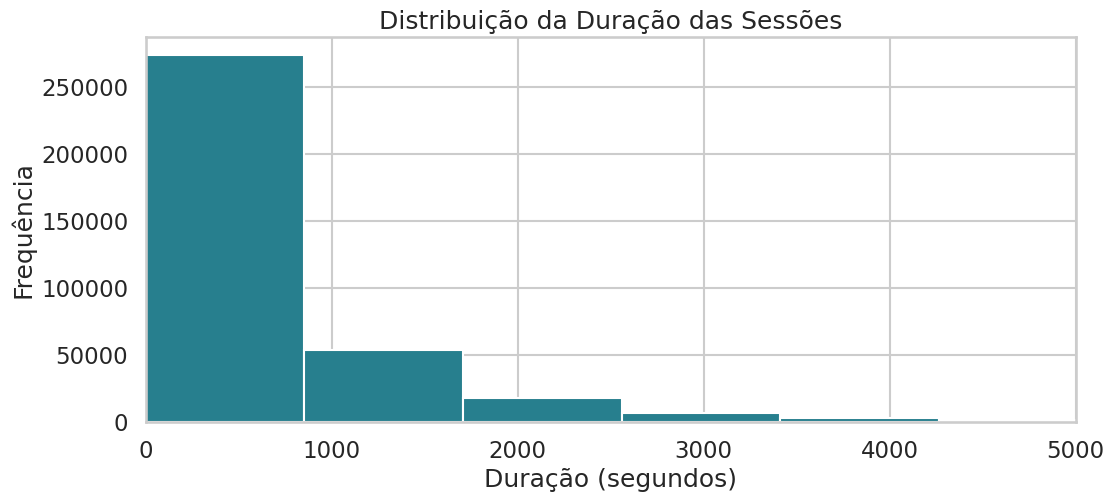

In [21]:

plt.figure(figsize=(12,5))

plt.hist(
    visits['session_duration'],
    bins=50,
    color=sns.color_palette(palette)[2]
)

plt.xlim(0, 5000)

plt.title('Distribuição da Duração das Sessões')
plt.xlabel('Duração (segundos)')
plt.ylabel('Frequência')
plt.grid(True)

plt.show()

### 📌 Interpretação

A duração das sessões apresenta grande variação, com predominância de sessões curtas.

A mediana é de 300 segundos (5 minutos), indicando que metade das sessões dura até esse tempo. Além disso, 75% das sessões não ultrapassam 840 segundos (14 minutos), mostrando que a maior parte das interações é relativamente rápida.

A média (643 segundos) é maior que a mediana, o que indica a presença de sessões mais longas que aumentam esse valor. Isso é reforçado pelo valor máximo elevado (42660 segundos), indicando a existência de alguns casos de sessões muito longas.

De forma geral, os dados mostram que a maioria dos usuários passa pouco tempo na plataforma, enquanto uma pequena parcela apresenta sessões mais longas.

Esse comportamento sugere um nível moderado de engajamento, com oportunidade de aumentar o tempo de permanência dos usuários.

In [22]:
sessions_per_user = visits.groupby('uid').size()
sessions_per_user.describe()

count    228169.000000
mean          1.575139
std           4.646787
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         893.000000
dtype: float64

### 📌 Interpretação

A maioria dos usuários realiza apenas uma sessão na plataforma, como indicado pela mediana e pelos quartis (25%, 50% e 75%), todos iguais a 1.

A média ligeiramente superior a 1 mostra que alguns usuários retornam mais vezes, mas eles representam uma minoria.

O valor máximo elevado indica que existem poucos usuários com muitas sessões, o que sugere a presença de uma pequena parcela mais engajada.

De forma geral, os dados indicam baixa retenção de usuários, com a maioria acessando a plataforma apenas uma vez.

### 🔁 Frequência de Retorno dos Usuários

In [23]:
first_visit = visits.groupby('uid')['start_ts'].min().reset_index()
first_visit.columns = ['uid', 'first_visit_date']

In [24]:
visits = visits.merge(first_visit, on='uid')

In [25]:
visits['cohort'] = visits['first_visit_date'].dt.to_period('M')
visits['visit_month'] = visits['start_ts'].dt.to_period('M')

In [26]:
visits['cohort_lifetime'] = (
    visits['visit_month'] - visits['cohort']
).apply(lambda x: x.n)

In [27]:
cohort_data = visits.groupby(['cohort', 'cohort_lifetime'])['uid'].nunique().reset_index()

retention_table = cohort_data.pivot_table(
    index='cohort',
    columns='cohort_lifetime',
    values='uid'
)

In [59]:
retention = retention_table.div(retention_table.iloc[:,0], axis=0)

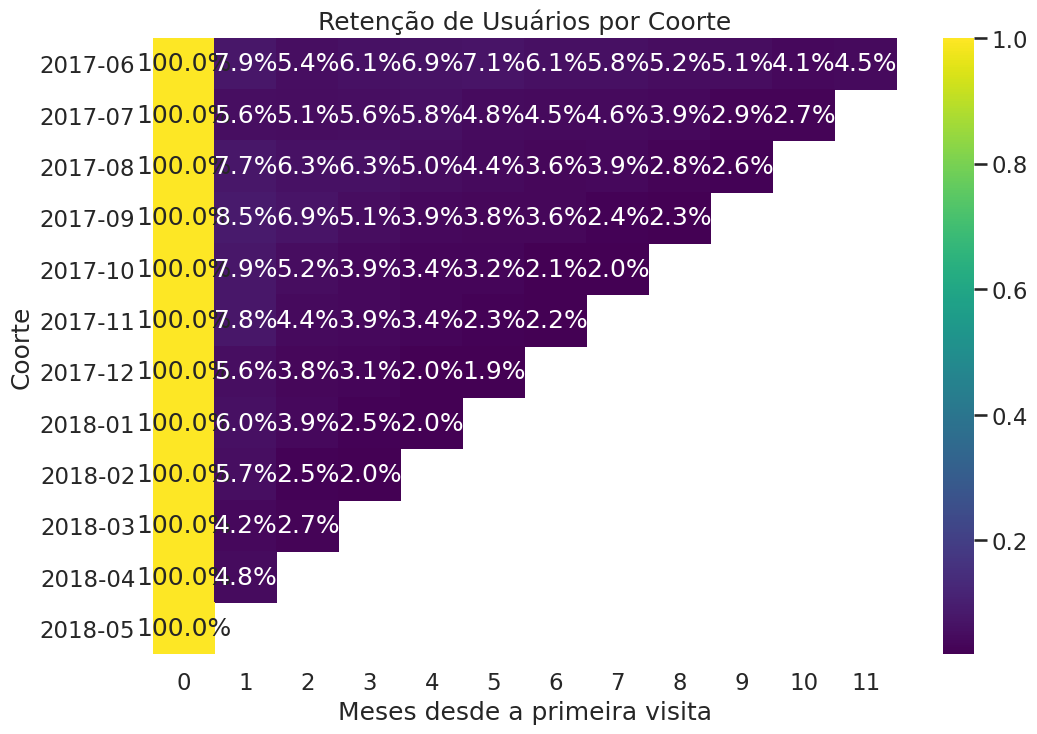

In [62]:

plt.figure(figsize=(12,8))

sns.heatmap(
    retention,
    annot=True,
    fmt='.1%',
    cmap=palette
)

plt.title('Retenção de Usuários por Coorte')
plt.xlabel('Meses desde a primeira visita')
plt.ylabel('Coorte')

plt.show()

### 📌 Interpretação


A retenção de usuários apresenta uma queda significativa logo após o primeiro mês.

Em média, cerca de 6,5% dos usuários retornam no mês seguinte, indicando baixa retenção inicial. Observa-se que todas as coortes começam com 100% no mês 0, mas já no mês 1 ocorre uma forte redução.

Nos meses seguintes, a retenção continua diminuindo de forma gradual, até se estabilizar em níveis baixos, geralmente entre 2% e 5%.

Isso mostra que a maior parte dos usuários não retorna após a primeira experiência com a plataforma, enquanto apenas uma pequena parcela mantém uso ao longo do tempo.

De forma geral, os dados indicam baixa retenção e sugerem a necessidade de estratégias para aumentar o engajamento e incentivar o retorno dos usuários.

### 💰 Análise de Vendas

Nesta seção, iremos analisar o comportamento de compra dos usuários.

Serão avaliadas métricas como:

- Tempo até a conversão (primeira compra)
- Número de pedidos por usuário
- Ticket médio (valor médio por pedido)
- LTV (Lifetime Value — receita total por cliente)

O objetivo é entender como os usuários se convertem em clientes e qual o valor que eles geram para a empresa.

In [30]:
first_order = orders.groupby('uid')['buy_ts'].min().reset_index()
first_order.columns = ['uid', 'first_order_date']

In [31]:
conversion = first_visit.merge(first_order, on='uid')

In [32]:
conversion['conversion_days'] = (
    conversion['first_order_date'] - conversion['first_visit_date']
).dt.days

In [33]:
conversion['conversion_days'].describe()

count    36523.000000
mean        16.729869
std         46.959088
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        363.000000
Name: conversion_days, dtype: float64

### 📌 Interpretação

A mediana do tempo até a primeira compra é de 0 dias, indicando que a maioria dos usuários realiza uma compra no mesmo dia em que acessa a plataforma pela primeira vez.

Os quartis reforçam esse comportamento, com 75% dos usuários convertendo em até 2 dias.

A média é significativamente maior (cerca de 16 dias), o que indica a presença de outliers — usuários que levam muito mais tempo para realizar a primeira compra.

De forma geral, os dados mostram que, quando a conversão acontece, ela tende a ocorrer rapidamente, sugerindo que a decisão de compra é tomada logo nos primeiros contatos com o produto.

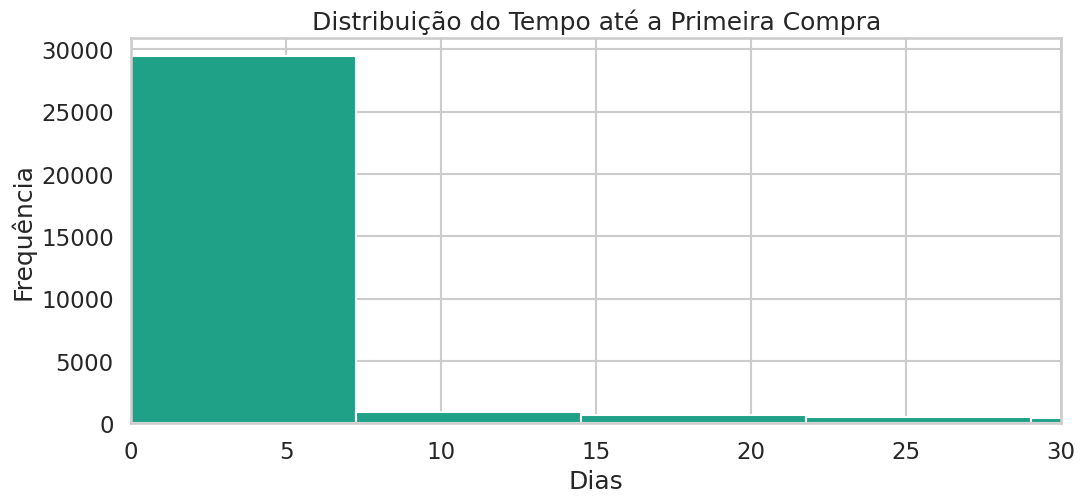

In [34]:
plt.figure(figsize=(12,5))

plt.hist(
    conversion['conversion_days'],
    bins=50,
    color=sns.color_palette(palette)[3]
)

plt.xlim(0, 30)

plt.title('Distribuição do Tempo até a Primeira Compra')
plt.xlabel('Dias')
plt.ylabel('Frequência')
plt.grid(True)

plt.show()

### 📌 Interpretação

A distribuição do tempo até a primeira compra indica que a conversão ocorre majoritariamente de forma rápida.

A mediana igual a 0 dias mostra que pelo menos metade dos usuários realiza a primeira compra no mesmo dia da primeira visita. Além disso, 75% dos usuários convertem em até 2 dias, reforçando a ideia de que a decisão de compra acontece nos primeiros contatos com a plataforma.

Por outro lado, a média (aproximadamente 16 dias) é significativamente superior à mediana, indicando a presença de outliers — usuários que levam muito mais tempo para converter, o que gera uma cauda longa na distribuição.

De forma geral, os dados mostram que, quando a conversão ocorre, ela tende a ser imediata ou muito rápida, sugerindo que o desempenho do produto depende fortemente da capacidade de impactar o usuário já nas primeiras interações.

In [35]:
orders_per_user = orders.groupby('uid').size()
orders_per_user.describe()

count    36523.000000
mean         1.380363
std          3.454461
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        239.000000
dtype: float64

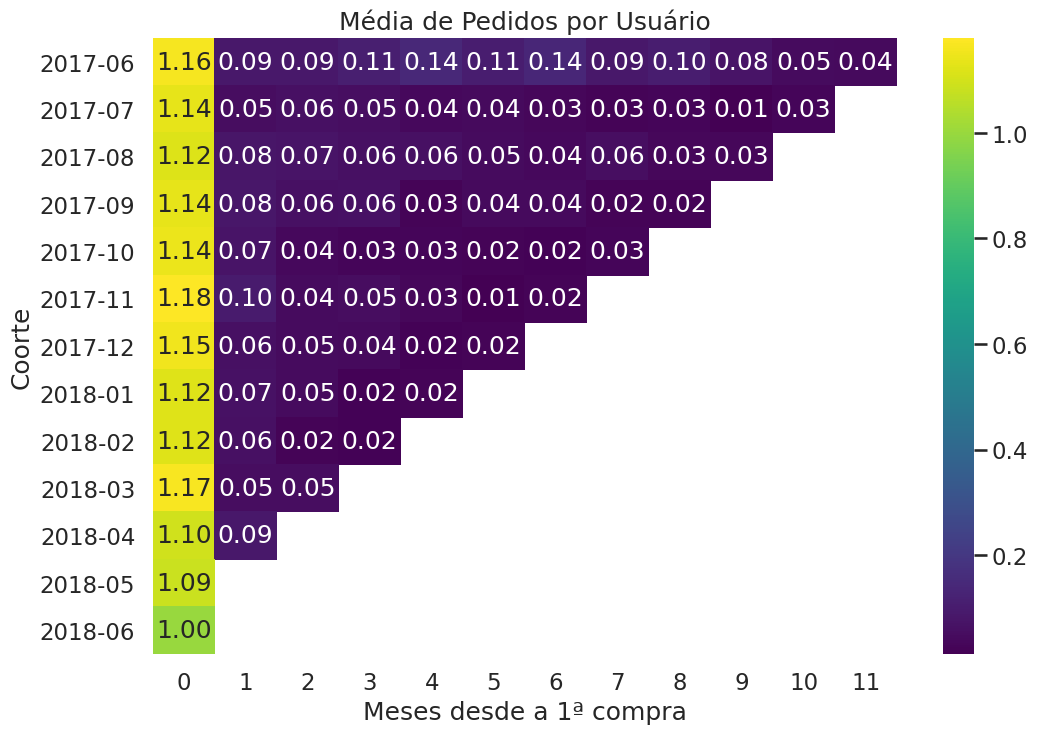

In [36]:
first_order_month = orders.groupby('uid')['buy_ts'].min().dt.to_period('M')
first_order_month.name = 'acquisition_month'

orders_with_cohort = orders.join(first_order_month, on='uid')

orders_with_cohort['order_month'] = orders_with_cohort['buy_ts'].dt.to_period('M')

orders_with_cohort['cohort_age'] = (
    orders_with_cohort['order_month'] - orders_with_cohort['acquisition_month']
).apply(lambda x: x.n)

orders_by_cohort = orders_with_cohort.pivot_table(
    index='acquisition_month',
    columns='cohort_age',
    values='uid',
    aggfunc='count'
)

cohort_size = orders_with_cohort.groupby('acquisition_month')['uid'].nunique()

avg_orders_pivot = orders_by_cohort.divide(cohort_size, axis=0)

plt.figure(figsize=(12,8))
sns.heatmap(avg_orders_pivot, annot=True, fmt='.2f', cmap='viridis')

plt.title('Média de Pedidos por Usuário')
plt.xlabel('Meses desde a 1ª compra')
plt.ylabel('Coorte')

plt.show()

### 📌 Interpretação

A análise de coorte mostra que a média de pedidos por usuário é mais alta no momento da aquisição (cohort_age = 0), com valores em torno de 1.12 a 1.18, indicando que alguns usuários realizam mais de um pedido já no primeiro mês.

Nos períodos seguintes, observa-se uma queda acentuada no número médio de pedidos, com valores geralmente abaixo de 0.1 a partir do primeiro mês após a aquisição.

Esse comportamento indica que a maioria dos usuários não realiza compras recorrentes ao longo do tempo, concentrando suas interações no período inicial.

Embora existam pequenas variações entre as coortes, o padrão geral se mantém consistente, sugerindo baixa retenção de clientes em termos de compras.

De forma geral, os dados reforçam que o produto apresenta baixa recorrência, com a maior parte da receita sendo gerada no momento inicial de aquisição.

In [38]:
orders['revenue'].describe()

count    50415.000000
mean         4.999647
std         21.818359
min          0.000000
25%          1.220000
50%          2.500000
75%          4.890000
max       2633.280000
Name: revenue, dtype: float64

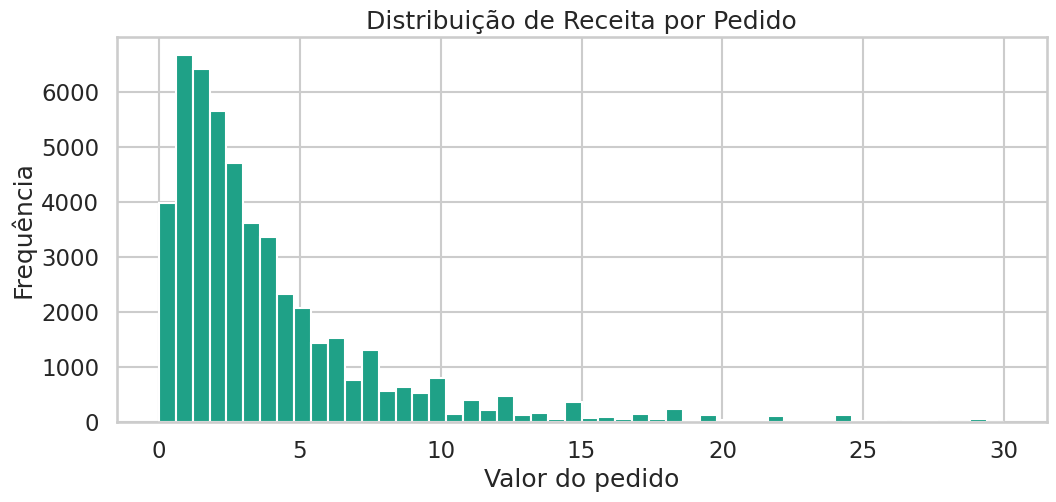

In [39]:


plt.figure(figsize=(12,5))

plt.hist(
    orders['revenue'],
    bins=50,
    range=(0, 30),
    color=sns.color_palette(palette)[3]
)

plt.title('Distribuição de Receita por Pedido')
plt.xlabel('Valor do pedido')
plt.ylabel('Frequência')
plt.grid(True)

plt.show()

### 📌 Interpretação

A distribuição da receita por pedido é altamente assimétrica, com forte concentração em valores baixos e presença de outliers elevados.

A mediana de aproximadamente 2,5 indica que a maior parte das transações possui baixo valor, enquanto 75% dos pedidos não ultrapassam cerca de 4,9.

Por outro lado, a média é significativamente maior (≈ 5), influenciada por poucos pedidos de alto valor — evidenciado também pelo valor máximo elevado.

Esse padrão indica que a receita está concentrada em uma pequena parcela de transações mais expressivas, enquanto a maioria dos pedidos contribui com valores reduzidos.

De forma geral, o comportamento sugere baixo ticket médio e dependência de outliers para aumento da receita total.

In [40]:
orders['order_month'] = orders['buy_ts'].dt.to_period('M')

orders['acquisition_month'] = orders.groupby('uid')['buy_ts'].transform('min').dt.to_period('M')

orders['cohort_lifetime'] = (
    orders['order_month'] - orders['acquisition_month']
).apply(lambda x: x.n)

In [41]:
orders.head()

,buy_ts,revenue,uid,order_month,acquisition_month,cohort_lifetime
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06,2017-06,0
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06,2017-06,0
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06,2017-06,0
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06,2017-06,0
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06,2017-06,0


In [42]:
cohorts_revenue = orders.groupby(
    ['acquisition_month', 'cohort_lifetime']
)['revenue'].sum().reset_index()

cohort_sizes = orders.groupby('acquisition_month')['uid'].nunique().reset_index()
cohort_sizes.columns = ['acquisition_month', 'n_buyers']

cohorts_data = pd.merge(cohorts_revenue, cohort_sizes, on='acquisition_month')

cohorts_data['ltv'] = cohorts_data['revenue'] / cohorts_data['n_buyers']

ltv_pivot = cohorts_data.pivot_table(
    index='acquisition_month',
    columns='cohort_lifetime',
    values='ltv',
    aggfunc='sum'
).cumsum(axis=1)

ltv_pivot

cohort_lifetime,0,1,2,3,4,5,6,7,8,9,10,11
acquisition_month,,,,,,,,,,,,
2017-06,4.724414,5.209743,5.647380,6.602051,7.624582,8.360084,9.310524,9.892116,10.445329,11.051117,11.622378,11.879234
2017-07,6.010218,6.345429,6.968960,7.327936,7.504727,7.660775,7.780983,7.922803,8.084035,8.231180,8.386854,NaN
2017-08,5.276518,5.748511,6.206993,6.598270,7.092321,7.375861,7.586526,7.991533,8.283745,8.471723,NaN,NaN
2017-09,5.644529,6.762115,7.283045,11.258838,11.659396,12.306463,13.008071,13.251220,13.435227,NaN,NaN,NaN
2017-10,5.003733,5.539495,5.730889,5.888035,6.039594,6.159956,6.244772,6.360242,NaN,NaN,NaN,NaN
2017-11,5.154683,5.553916,5.753472,6.078424,6.226437,6.280316,6.395244,NaN,NaN,NaN,NaN,NaN
2017-12,4.738191,4.998565,5.923662,6.988937,7.301866,7.639913,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,4.135636,4.430394,4.734675,4.877453,4.940151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,4.156987,4.435262,4.513777,4.587921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


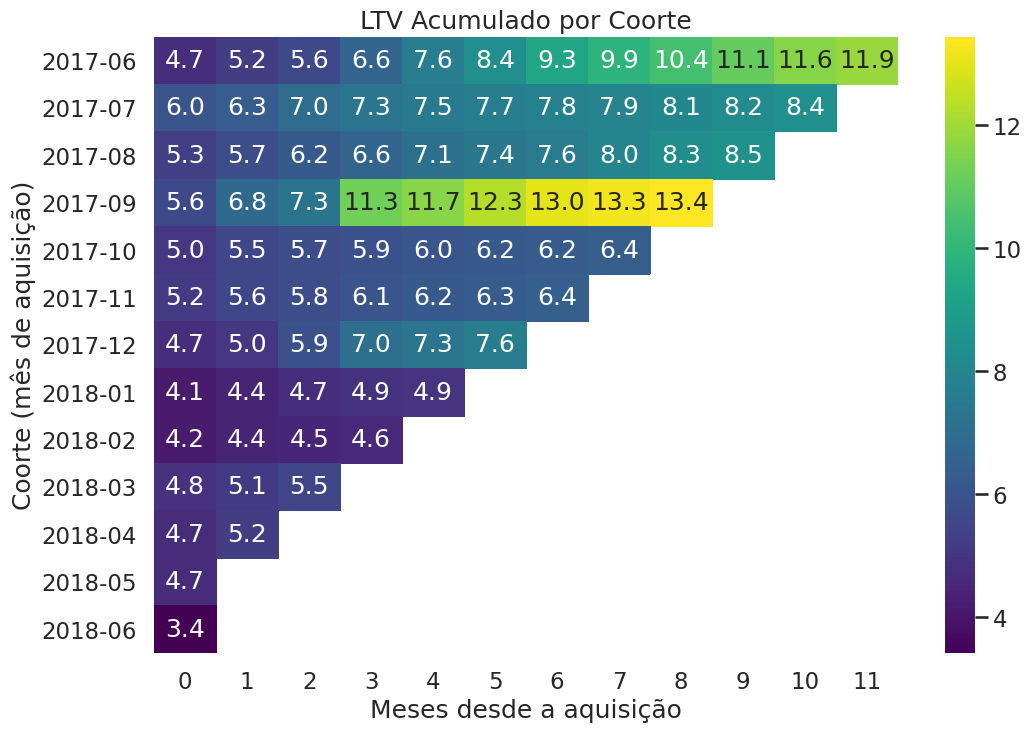

In [43]:
plt.figure(figsize=(12,8))

sns.heatmap(
    ltv_pivot,
    annot=True,
    fmt='.1f',
    cmap='viridis'
)

plt.title('LTV Acumulado por Coorte')
plt.xlabel('Meses desde a aquisição')
plt.ylabel('Coorte (mês de aquisição)')

plt.show()


### 📌 Interpretação

O LTV médio apresenta crescimento ao longo do tempo, passando de aproximadamente 4.8 no mês inicial para valores acima de 10 nas coortes mais maduras, indicando que os usuários continuam gerando receita após a aquisição.

Observa-se que o maior incremento ocorre nos primeiros meses do ciclo de vida, com aumentos progressivos, porém cada vez menores, ao longo do tempo. Esse comportamento indica que a monetização é mais intensa no início e tende a desacelerar posteriormente.

A dispersão dos dados (desvio padrão crescente ao longo dos meses) sugere variação significativa entre coortes, indicando diferenças na qualidade dos usuários adquiridos ou na eficiência dos canais de aquisição.

Além disso, embora algumas coortes atinjam valores elevados de LTV, a mediana cresce de forma mais moderada, reforçando que a maior parte dos usuários gera receita relativamente baixa, enquanto poucos usuários concentram valores mais altos.

De forma geral, o padrão observado indica que o crescimento do LTV é consistente, porém limitado, o que pode refletir desafios relacionados à retenção e à recorrência de compras ao longo do tempo.

### 📢 Análise de Marketing

Nesta seção, iremos analisar os investimentos em marketing e avaliar sua eficiência.

Serão analisadas métricas como:

- Investimento total e por origem
- CAC (Customer Acquisition Cost)
- ROI (Return on Investment)

O objetivo é entender se os investimentos estão gerando retorno positivo e quais canais são mais eficientes.

In [45]:
costs.describe()

,source_id,costs
count,2542.000000,2542.000000
mean,4.857199,129.477427
std,3.181581,156.296628
min,1.000000,0.540000
25%,2.000000,21.945000
50%,4.000000,77.295000
75%,9.000000,170.065000
max,10.000000,1788.280000


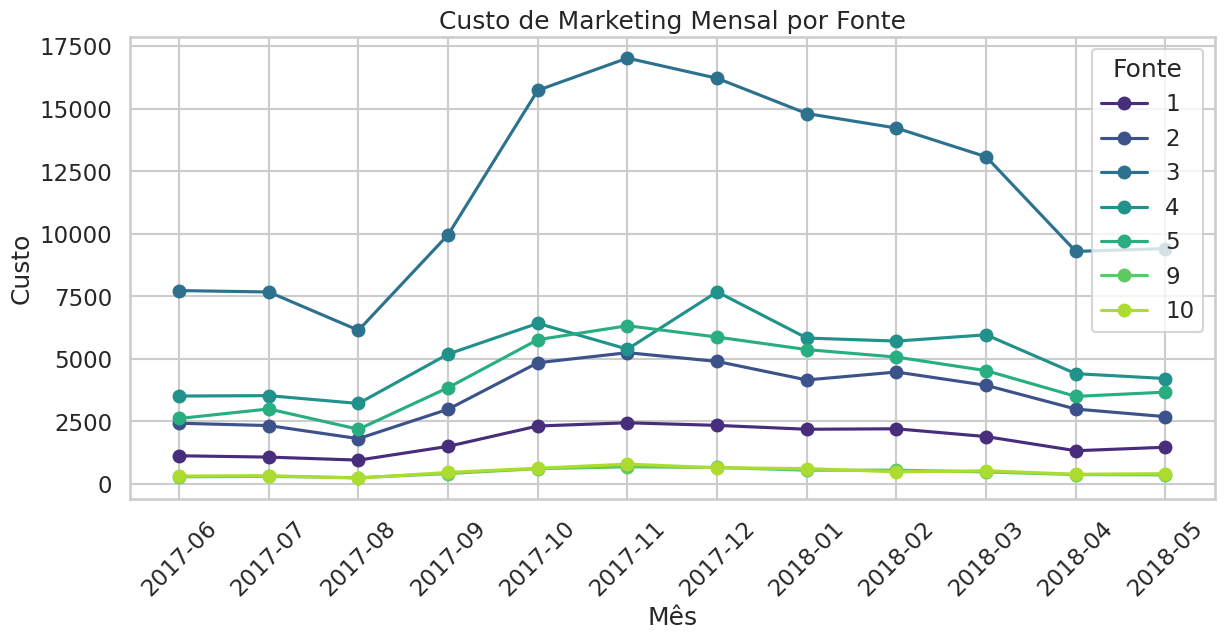

In [46]:
costs['month'] = costs['dt'].dt.to_period('M')

costs_pivot = costs.pivot_table(
    index='month',
    columns='source_id',
    values='costs',
    aggfunc='sum'
).fillna(0)

plt.figure(figsize=(14,6))

colors = sns.color_palette(palette, n_colors=len(costs_pivot.columns))

for i, col in enumerate(costs_pivot.columns):
    plt.plot(
        costs_pivot.index.astype(str),
        costs_pivot[col],
        marker='o',
        color=colors[i],
        label=col
    )

plt.title('Custo de Marketing Mensal por Fonte')
plt.xlabel('Mês')
plt.ylabel('Custo')
plt.legend(title='Fonte')
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

### 📌 Interpretação

Os investimentos em marketing apresentam variação relevante entre as diferentes fontes ao longo do tempo, indicando estratégias distintas de alocação de orçamento.

A Source Id 3 concentra o maior volume de investimento, com ampla diferença em relação às demais fontes, seguida pelas Sources Id 4, 5 e 2. Esse padrão sugere uma priorização significativa desse canal na estratégia de aquisição de usuários.

Por outro lado, as Sources Id 9 e 10 apresentam níveis de investimento consideravelmente mais baixos, indicando atuação mais limitada ou testes em menor escala.

A análise temporal mostra que os custos mensais variam de forma consistente dentro de cada fonte, sem oscilações extremamente abruptas, o que pode indicar uma estratégia relativamente estável de investimento ao longo do período.

De forma geral, observa-se uma forte concentração de recursos em poucos canais, o que reforça a importância de avaliar a eficiência desses investimentos nas etapas seguintes (CAC e ROI), a fim de garantir que o alto volume de gastos esteja sendo convertido em retorno proporcional.

In [48]:
first_source = visits.sort_values('start_ts').drop_duplicates('uid')[['uid', 'source_id']]
orders_with_source = orders.merge(first_source, on='uid')

customers_per_source = orders_with_source.groupby('source_id')['uid'].nunique()

costs_per_source = costs.groupby('source_id')['costs'].sum()

cac = costs_per_source / customers_per_source
cac

source_id
1      7.186364
2     12.209367
3     13.493901
4      5.931779
5      7.467479
7           NaN
9      5.071222
10     4.381106
dtype: float64

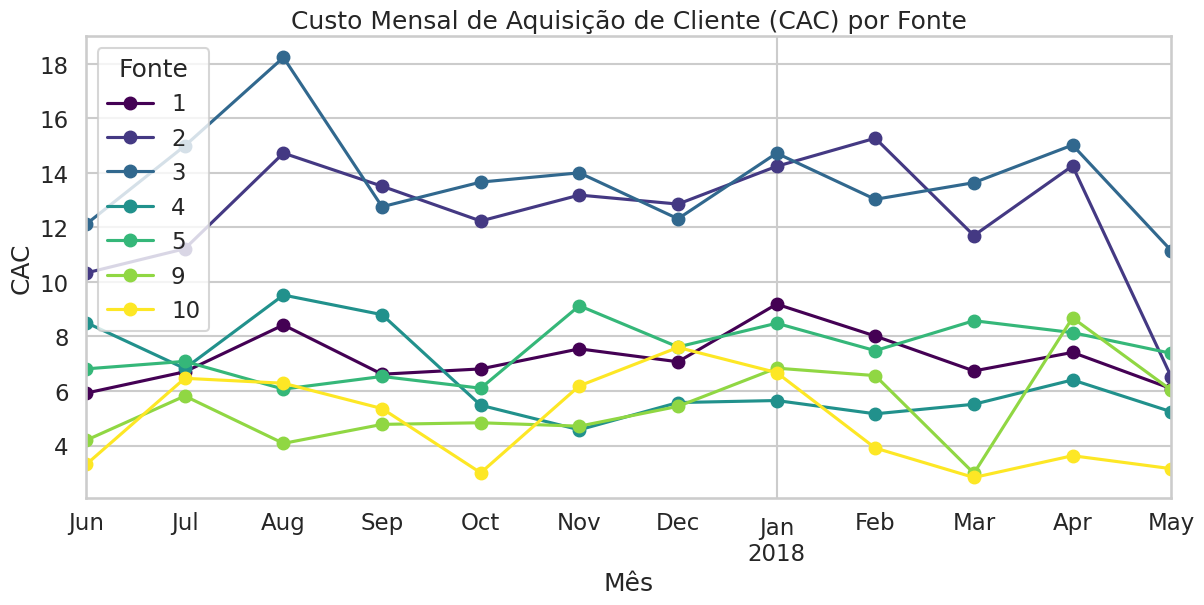

In [49]:
costs['month'] = costs['dt'].dt.to_period('M')

first_visits = visits.sort_values('start_ts').drop_duplicates('uid')
first_visits = first_visits[['uid', 'source_id']]

first_orders = orders.sort_values('buy_ts').drop_duplicates('uid')
first_orders['acquisition_month'] = first_orders['buy_ts'].dt.to_period('M')
first_orders = first_orders[['uid', 'acquisition_month']]

buyers = pd.merge(first_orders, first_visits, on='uid')

buyers_by_month_source = buyers.groupby(
    ['acquisition_month', 'source_id']
)['uid'].nunique().reset_index()

buyers_by_month_source.columns = ['month', 'source_id', 'n_buyers']

costs_by_month_source = costs.groupby(
    ['month', 'source_id']
)['costs'].sum().reset_index()

cac_monthly_data = pd.merge(
    costs_by_month_source,
    buyers_by_month_source,
    on=['month', 'source_id']
)

cac_monthly_data = cac_monthly_data[cac_monthly_data['n_buyers'] > 0]

cac_monthly_data['cac'] = cac_monthly_data['costs'] / cac_monthly_data['n_buyers']

cac_pivot = cac_monthly_data.pivot_table(
    index='month',
    columns='source_id',
    values='cac'
)

plt.figure(figsize=(14,6))

cac_pivot.plot(
    ax=plt.gca(),
    marker='o',
    colormap='viridis'
)

plt.title('Custo Mensal de Aquisição de Cliente (CAC) por Fonte')
plt.xlabel('Mês')
plt.ylabel('CAC')
plt.legend(title='Fonte')
plt.grid(True)

plt.show()

### 📌 Interpretação

O custo de aquisição de clientes (CAC) apresenta variação relevante entre as fontes de marketing, com média geral de aproximadamente **8**.

Observa-se que algumas fontes são significativamente mais eficientes:
- As fontes **9 e 10** apresentam os menores CACs (≈ 4,87 e 5,41), indicando aquisição de clientes com menor investimento.
- Já as fontes **2 e 3** possuem os maiores custos (≈ 12,50 e 13,80), sugerindo menor eficiência na conversão de investimento em clientes.

Essa diferença indica que nem todas as fontes de tráfego geram clientes com o mesmo custo, evidenciando oportunidades de otimização no mix de marketing.

A fonte 7 não apresenta CAC calculável, pois não houve clientes convertidos registrados nessa origem durante o período analisado.

Além disso, a dispersão dos valores (desvio padrão ≈ **3,62**) sugere que o CAC varia ao longo do tempo, possivelmente influenciado por sazonalidade ou mudanças nas campanhas.

### 📊 Insight Estratégico

- Priorizar investimentos nas fontes mais eficientes (**9 e 10**)
- Reavaliar ou otimizar campanhas nas fontes com maior custo (**2 e 3**)

### 📌 Conclusão

O CAC evidencia diferenças importantes de eficiência entre as fontes de aquisição, indicando potencial para otimização de investimentos. No entanto, essa análise deve ser considerada em conjunto com o LTV, garantindo que decisões sejam baseadas na rentabilidade e não apenas no custo.


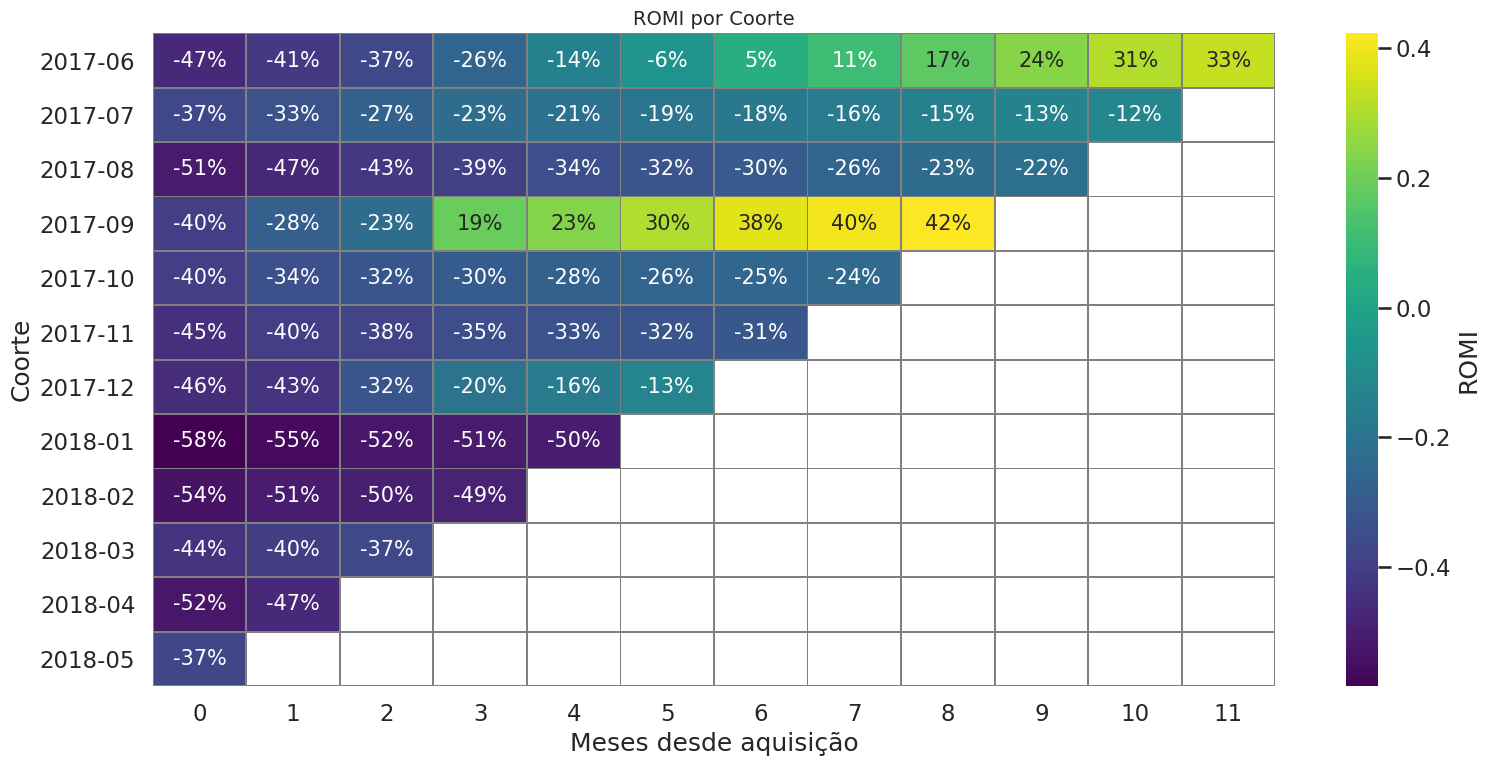

In [51]:
orders['acquisition_month'] = orders.groupby('uid')['buy_ts'].transform('min').dt.to_period('M')
orders['order_month'] = orders['buy_ts'].dt.to_period('M')

orders['cohort_lifetime'] = (
    orders['order_month'] - orders['acquisition_month']
).apply(lambda x: x.n)

cohorts_revenue = orders.groupby(
    ['acquisition_month', 'cohort_lifetime']
)['revenue'].sum().reset_index()

cohort_sizes = orders.groupby('acquisition_month')['uid'].nunique().reset_index()
cohort_sizes.columns = ['acquisition_month', 'n_buyers']

cohorts_data = pd.merge(cohorts_revenue, cohort_sizes, on='acquisition_month')
cohorts_data['ltv'] = cohorts_data['revenue'] / cohorts_data['n_buyers']

ltv_pivot = cohorts_data.pivot_table(
    index='acquisition_month',
    columns='cohort_lifetime',
    values='ltv'
).cumsum(axis=1)

costs['month'] = costs['dt'].dt.to_period('M')

first_orders = orders.sort_values('buy_ts').drop_duplicates('uid')
first_orders['acquisition_month'] = first_orders['buy_ts'].dt.to_period('M')

n_buyers_by_cohort = first_orders.groupby('acquisition_month')['uid'].nunique().reset_index()
n_buyers_by_cohort.columns = ['month', 'n_buyers']

costs_by_cohort = costs.groupby('month')['costs'].sum().reset_index()

cac_by_cohort = pd.merge(costs_by_cohort, n_buyers_by_cohort, on='month')
cac_by_cohort['cac'] = cac_by_cohort['costs'] / cac_by_cohort['n_buyers']
cac_by_cohort = cac_by_cohort[['month', 'cac']]
cac_by_cohort.columns = ['acquisition_month', 'cac']

report = pd.merge(ltv_pivot.reset_index(), cac_by_cohort, on='acquisition_month')
report = report.set_index('acquisition_month')

cac_values = report['cac']
ltv_values = report.drop(columns=['cac'])

romi_pivot = ltv_values.subtract(cac_values, axis=0).divide(cac_values, axis=0)

plt.figure(figsize=(16,8))

sns.heatmap(
    romi_pivot,
    annot=True,
    fmt='.0%',
    cmap='viridis',
    linewidths=0.5,
    linecolor='gray',
    annot_kws={"size":15},
    cbar_kws={'label': 'ROMI'}
)

plt.title('ROMI por Coorte', fontsize=14)
plt.xlabel('Meses desde aquisição')
plt.ylabel('Coorte')

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 📌 Interpretação

A análise do ROMI (Return on Marketing Investment) mostra que, nos primeiros meses após a aquisição, o retorno sobre o investimento é predominantemente negativo.

Nos meses iniciais (0 a 5), o ROMI médio varia de aproximadamente **-46% a -14%**, indicando que o valor gerado pelos clientes ainda não é suficiente para cobrir os custos de aquisição nesse período.

Com o passar do tempo, observa-se uma melhora gradual no retorno. A partir dos meses mais avançados, o ROMI se aproxima do ponto de equilíbrio e, em alguns casos, torna-se positivo.

Esse comportamento indica que o modelo de negócio depende do tempo para recuperar o investimento em marketing, ou seja, os clientes passam a gerar valor apenas no médio prazo.

### 📊 Insight Estratégico

- O investimento em marketing não se paga no curto prazo  
- O retorno ocorre de forma gradual, ao longo do tempo  
- A retenção de usuários é fundamental para garantir a rentabilidade  

### 📌 Conclusão

Os resultados indicam que, embora o marketing não gere retorno imediato, ele pode se tornar lucrativo ao longo do tempo. No entanto, isso depende diretamente da capacidade da empresa de reter usuários e aumentar seu valor ao longo do ciclo de vida.

Dessa forma, investir apenas em aquisição sem melhorar retenção e monetização pode comprometer a sustentabilidade do crescimento.

In [52]:
first_source = visits.sort_values('start_ts').drop_duplicates('uid')[['uid', 'source_id']]

orders_with_source = orders.merge(first_source, on='uid')

revenue_per_source = orders_with_source.groupby('source_id')['revenue'].sum()

roi = (revenue_per_source - costs_per_source) / costs_per_source
roi

source_id
1     0.492351
2     0.096191
3    -0.614275
4    -0.071664
5     0.016750
7          NaN
9     0.043844
10   -0.235665
dtype: float64

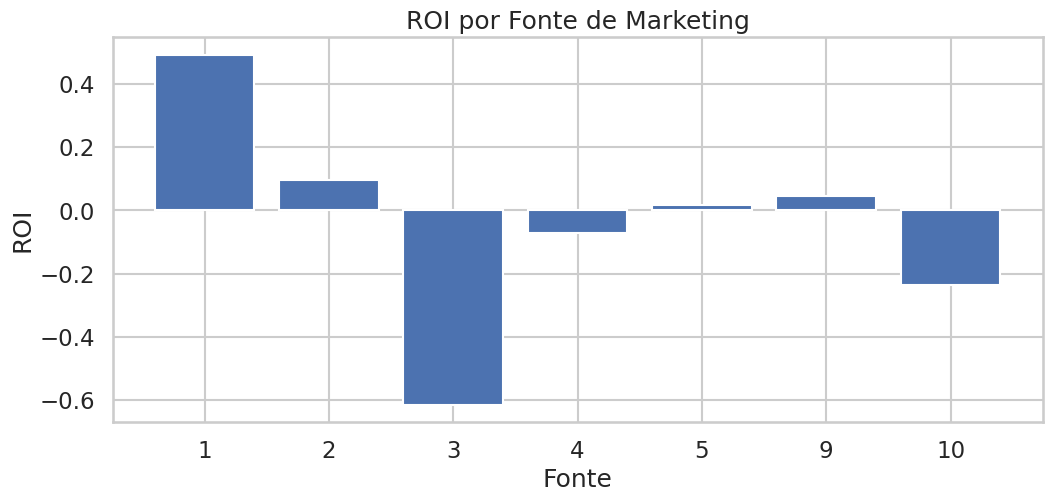

In [53]:
roi = roi.dropna()

plt.figure(figsize=(12,5))

plt.bar(
    roi.index.astype(str),
    roi.values
)

plt.title('ROI por Fonte de Marketing')
plt.xlabel('Fonte')
plt.ylabel('ROI')
plt.grid(True)

plt.show()

### 📌 Interpretação

O ROI varia significativamente entre as diferentes origens de tráfego.

A Source Id 1 se destaca como o canal mais eficiente, apresentando retorno positivo relevante sobre o investimento.

As Sources Id 2, 5 e 9 apresentam ROI próximo de zero, indicando que operam próximas ao ponto de equilíbrio, gerando pouco lucro.

Por outro lado, as Sources Id 3, 4 e 10 apresentam ROI negativo, indicando que o investimento nesses canais não está sendo recuperado.

Esses resultados mostram que parte dos investimentos em marketing não está gerando retorno positivo, sendo necessário reavaliar a alocação de recursos.


### 📊 Conclusão Final

A análise dos dados permitiu entender o comportamento dos usuários, a eficiência das fontes de aquisição e o retorno financeiro das estratégias de marketing da Y.Afisha.

### 👤 Comportamento dos Usuários

Os dados de atividade (DAU, WAU e MAU) mostram que a plataforma mantém uma base ativa de usuários ao longo do tempo, com crescimento gradual no período analisado.

A maior parte dos usuários realiza poucas sessões e permanece pouco tempo em cada visita, indicando baixo nível de recorrência. A retenção por coorte também mostra queda acentuada após o primeiro mês, o que sugere dificuldade em manter usuários ativos no longo prazo.

Além disso, a maioria das conversões acontece rapidamente: muitos usuários realizam a primeira compra no mesmo dia da primeira visita, mostrando que a decisão de compra tende a ocorrer logo no início da jornada.

### 🛒 Retenção e Receita (LTV)

A análise de LTV mostra que:

* A maior parte da receita é gerada nos primeiros meses após a aquisição;
* O crescimento do LTV é gradual ao longo do tempo;
* Coortes mais antigas acumulam maior valor.

Esse comportamento indica que o negócio depende fortemente da conversão inicial, enquanto a recompra e retenção têm impacto mais limitado no longo prazo.

### 💰 Custos de Marketing

Os investimentos em marketing variam significativamente entre as fontes de aquisição.

* Algumas fontes concentram grande parte do orçamento;
* Outras operam com investimento menor, mas ainda relevante.

Isso mostra que a empresa depende fortemente de poucos canais principais, tornando essencial avaliar constantemente sua eficiência.

### 🎯 CAC (Custo de Aquisição de Cliente)

O CAC apresenta diferenças relevantes entre as fontes:

* Fontes 9 e 10 possuem os menores custos de aquisição;
* Fontes 2 e 3 apresentam CAC mais elevado.

Esses resultados mostram que algumas fontes conseguem atrair clientes com menor custo, enquanto outras exigem investimento maior para gerar conversões.

### 📈 ROI e ROMI

A análise de ROI mostra que nem todas as fontes são lucrativas.

* A Source ID 1 apresenta o melhor retorno;
* Sources 3, 4 e 10 apresentam ROI negativo;
* Algumas fontes operam próximas ao ponto de equilíbrio.

O ROMI por coorte mostra que o retorno do investimento em marketing não acontece no curto prazo. Nos primeiros meses, o retorno tende a ser negativo, tornando-se melhor apenas com o passar do tempo.

Isso indica que a rentabilidade depende da retenção e da capacidade de monetizar usuários ao longo do ciclo de vida.

### 🚀 Recomendações Estratégicas

Com base nos resultados, recomenda-se:

* Reduzir ou reavaliar investimentos em fontes com ROI negativo;
* Priorizar canais com menor CAC e melhor retorno;
* Investir em estratégias de retenção para aumentar o LTV;
* Melhorar ações de engajamento para aumentar recorrência e tempo de sessão;
* Otimizar o funil inicial de conversão para aproveitar a alta taxa de compra no primeiro contato.

### ✅ Conclusão Geral

A Y.Afisha apresenta boa capacidade de conversão inicial, mas enfrenta desafios importantes em retenção e eficiência de marketing.

O principal potencial de crescimento está em:

* Melhorar a retenção de usuários;
* Aumentar o valor gerado por cliente ao longo do tempo;
* Direcionar investimentos para canais mais rentáveis.

Com ajustes estratégicos nesses pontos, a empresa pode aumentar significativamente sua rentabilidade.